## 1. Tree-Based Methods

Import packages

In [10]:
from __future__ import annotations
try:
    import warnings
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns
    import os
    from xgboost import XGBClassifier
    from collections import defaultdict
    from sklearn.svm import SVC
    from pathlib import Path
    from dataclasses import dataclass
    from typing import Tuple, Dict
    from sklearn.experimental import enable_iterative_imputer
    from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer 
    from sklearn.preprocessing import StandardScaler
    from imblearn.over_sampling import SMOTE
    from sklearn.linear_model import LogisticRegression
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.pipeline import Pipeline
    from sklearn.svm import SVC
    from sklearn.model_selection import (
        KFold, StratifiedKFold, GridSearchCV, cross_val_score
    )
    from sklearn.metrics import (
        confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score, auc, 
    classification_report, precision_recall_curve, accuracy_score)
    print("Imported all packages successfully.!")
except Exception as e:
    print(f"Error importing the following packages: {e}")
    print("Installing the non-present packages!!..")
    %pip install -r "requirements.txt"
    warnings.filterwarnings("ignore")
    print("Installation Successfull")

Imported all packages successfully.!


### (a) Download the APS Failure data

In [2]:
TRAIN_PATH = Path("../data/aps_failure_training_set.csv")
TEST_PATH = Path("../data/aps_failure_test_set.csv")
data_paths = [TRAIN_PATH, TEST_PATH]

def load_data(paths: [str]) -> [pd.DataFrame]:
    try:
        res = []
        for path in paths:
            if path.exists():
                header_ = 0
                with open(path, 'r', encoding='utf-8') as file:
                    for i, line in enumerate(file):
                        if line.strip().lower().startswith('class'):
                            header_ =  i
                            break
                    else:
                        raise AttributeError("The header starting with 'class' was not found!")
                print(f"Loading {path.name} with header at row {header_}!!")
                df = (pd.read_csv(path, skiprows=header_, na_values=["na"]))
                res.append(df)
            else:
                raise FileNotFoundError(f"Data Set file path not found: {path}")
        print("All good!")
        return res
    except Excpetion as e:
        print(f"Error loading data: {e}")
        return []

In [3]:
data_dfs = load_data(data_paths)
train_df = data_dfs[0]
test_df = data_dfs[1]

Loading aps_failure_training_set.csv with header at row 20!!
Loading aps_failure_test_set.csv with header at row 20!!
All good!


In [4]:
train_df.head(3)

,class,aa_000,ab_000,ac_000,ad_000,ae_000,af_000,ag_000,ag_001,ag_002,...,ee_002,ee_003,ee_004,ee_005,ee_006,ee_007,ee_008,ee_009,ef_000,eg_000
0,neg,76698,NaN,2.130706e+09,280.0,0.0,0.0,0.0,0.0,0.0,...,1240520.0,493384.0,721044.0,469792.0,339156.0,157956.0,73224.0,0.0,0.0,0.0
1,neg,33058,NaN,0.000000e+00,NaN,0.0,0.0,0.0,0.0,0.0,...,421400.0,178064.0,293306.0,245416.0,133654.0,81140.0,97576.0,1500.0,0.0,0.0
2,neg,41040,NaN,2.280000e+02,100.0,0.0,0.0,0.0,0.0,0.0,...,277378.0,159812.0,423992.0,409564.0,320746.0,158022.0,95128.0,514.0,0.0,0.0


In [5]:
test_df.head(3)

,class,aa_000,ab_000,ac_000,ad_000,ae_000,af_000,ag_000,ag_001,ag_002,...,ee_002,ee_003,ee_004,ee_005,ee_006,ee_007,ee_008,ee_009,ef_000,eg_000
0,neg,60,0.0,20.0,12.0,0.0,0.0,0.0,0.0,0.0,...,1098.0,138.0,412.0,654.0,78.0,88.0,0.0,0.0,0.0,0.0
1,neg,82,0.0,68.0,40.0,0.0,0.0,0.0,0.0,0.0,...,1068.0,276.0,1620.0,116.0,86.0,462.0,0.0,0.0,0.0,0.0
2,neg,66002,2.0,212.0,112.0,0.0,0.0,0.0,0.0,0.0,...,495076.0,380368.0,440134.0,269556.0,1315022.0,153680.0,516.0,0.0,0.0,0.0


In [6]:
print(" Shape of the given dataframes")
print(f"\n Shape of Training Data: {train_df.shape}")
print(f"\n Data Types of Training Data: {train_df.dtypes.unique()}")
print(f"\n Shape of Testing Data: {test_df.shape}")
print(f"\n Data Types of Testing Data: {test_df.dtypes.unique()}")
print("\n<----- Null Value location visualtion for training data ----->")
for i in train_df.columns:
    if train_df[i].isna().sum() > 0:
        print(f"\n Column Name: {i} --> Null values: {train_df[i].isna().sum()}")
print("\n<----- Null Value location visualtion for testing data ----->")
for j in test_df.columns:
    if test_df[j].isna().sum() > 0:
        print(f"\n Column Name: {j} --> Null values: {test_df[j].isna().sum()}")

 Shape of the given dataframes

 Shape of Training Data: (60000, 171)

 Data Types of Training Data: [dtype('O') dtype('int64') dtype('float64')]

 Shape of Testing Data: (16000, 171)

 Data Types of Testing Data: [dtype('O') dtype('int64') dtype('float64')]

<----- Null Value location visualtion for training data ----->

 Column Name: ab_000 --> Null values: 46329

 Column Name: ac_000 --> Null values: 3335

 Column Name: ad_000 --> Null values: 14861

 Column Name: ae_000 --> Null values: 2500

 Column Name: af_000 --> Null values: 2500

 Column Name: ag_000 --> Null values: 671

 Column Name: ag_001 --> Null values: 671

 Column Name: ag_002 --> Null values: 671

 Column Name: ag_003 --> Null values: 671

 Column Name: ag_004 --> Null values: 671

 Column Name: ag_005 --> Null values: 671

 Column Name: ag_006 --> Null values: 671

 Column Name: ag_007 --> Null values: 671

 Column Name: ag_008 --> Null values: 671

 Column Name: ag_009 --> Null values: 671

 Column Name: ah_000 -->

### (b) Data Preparation

#### (i) Research what types of techniques are usually used

In [7]:
"""Now that we have had a look at the null values in the columns and lets categorize them
    and group them according to their quantity
    Category1: 0-10% nan values --> imputation type --> median
    Category2: 11-45% nan values --> imputation type --> 2 Step KNN (custom)
    Category3: 46%-65% nan values --> imputation type --> 2 Step KNN (custom) --DROP the COLUMNS Selectively
    Category4: >66% nan values --> DROP THESE COLUMNS
    If we keep Category4 attributes they are just going to add noise, not give any strong signal
"""
def cat_classifier(df) -> {}:
    if df is not None and not df.empty:
        cat = defaultdict(list)
        for i in df.columns:
            nan_sum = df[i].isna().sum()
            rows = df[i].shape[0]
            if nan_sum > 0:
                concentration = nan_sum/rows
                if concentration <= 0.1:
                    cat['cat1'].append(i)
                elif concentration > 0.1 and concentration <= 0.45:
                    cat['cat2'].append(i)
                elif concentration > 0.45 and concentration <= 0.65:
                    cat['cat3'].append(i)
                else:
                    cat['cat4'].append(i)
            else:
                continue
        print("\n Category1 Columns:")
        print(f"\n Number of Cat 1 Columns: {len(cat['cat1'])}")
        print(f"\n{cat['cat1']}")
        print("\n Category2 Columns:")
        print(f"\n Number of Cat 2 Columns: {len(cat['cat2'])}")
        print(f"\n{cat['cat2']}")
        print("\n Category3 Columns:")
        print(f"\n Number of Cat 3 Columns: {len(cat['cat3'])}")
        print(f"\n{cat['cat3']}")
        print("\n Category4 Columns:")
        print(f"\n Number of Cat 4 Columns: {len(cat['cat4'])}")
        print(f"\n{cat['cat4']}")
        return cat
    else:
        print("No df provided!")
        return ['']


In [8]:
cat = cat_classifier(train_df)


 Category1 Columns:

 Number of Cat 1 Columns: 141

['ac_000', 'ae_000', 'af_000', 'ag_000', 'ag_001', 'ag_002', 'ag_003', 'ag_004', 'ag_005', 'ag_006', 'ag_007', 'ag_008', 'ag_009', 'ah_000', 'ai_000', 'aj_000', 'ak_000', 'al_000', 'am_0', 'an_000', 'ao_000', 'ap_000', 'aq_000', 'ar_000', 'as_000', 'at_000', 'au_000', 'av_000', 'ax_000', 'ay_000', 'ay_001', 'ay_002', 'ay_003', 'ay_004', 'ay_005', 'ay_006', 'ay_007', 'ay_008', 'ay_009', 'az_000', 'az_001', 'az_002', 'az_003', 'az_004', 'az_005', 'az_006', 'az_007', 'az_008', 'az_009', 'ba_000', 'ba_001', 'ba_002', 'ba_003', 'ba_004', 'ba_005', 'ba_006', 'ba_007', 'ba_008', 'ba_009', 'bb_000', 'bc_000', 'bd_000', 'be_000', 'bf_000', 'bg_000', 'bh_000', 'bi_000', 'bj_000', 'bs_000', 'bt_000', 'bu_000', 'bv_000', 'bx_000', 'by_000', 'bz_000', 'ca_000', 'cb_000', 'cc_000', 'cd_000', 'ce_000', 'ci_000', 'cj_000', 'ck_000', 'cn_000', 'cn_001', 'cn_002', 'cn_003', 'cn_004', 'cn_005', 'cn_006', 'cn_007', 'cn_008', 'cn_009', 'cp_000', 'cq_000'

In [9]:
"""After the above results we drop CATEGORY 4 columns"""
train_df.drop(columns=cat['cat4'], inplace=True)
train_df.shape

(60000, 163)

In [10]:
test_cat = cat_classifier(test_df)


 Category1 Columns:

 Number of Cat 1 Columns: 141

['ac_000', 'ae_000', 'af_000', 'ag_000', 'ag_001', 'ag_002', 'ag_003', 'ag_004', 'ag_005', 'ag_006', 'ag_007', 'ag_008', 'ag_009', 'ah_000', 'ai_000', 'aj_000', 'ak_000', 'al_000', 'am_0', 'an_000', 'ao_000', 'ap_000', 'aq_000', 'ar_000', 'as_000', 'at_000', 'au_000', 'av_000', 'ax_000', 'ay_000', 'ay_001', 'ay_002', 'ay_003', 'ay_004', 'ay_005', 'ay_006', 'ay_007', 'ay_008', 'ay_009', 'az_000', 'az_001', 'az_002', 'az_003', 'az_004', 'az_005', 'az_006', 'az_007', 'az_008', 'az_009', 'ba_000', 'ba_001', 'ba_002', 'ba_003', 'ba_004', 'ba_005', 'ba_006', 'ba_007', 'ba_008', 'ba_009', 'bb_000', 'bc_000', 'bd_000', 'be_000', 'bf_000', 'bg_000', 'bh_000', 'bi_000', 'bj_000', 'bs_000', 'bt_000', 'bu_000', 'bv_000', 'bx_000', 'by_000', 'bz_000', 'ca_000', 'cb_000', 'cc_000', 'cd_000', 'ce_000', 'ci_000', 'cj_000', 'ck_000', 'cn_000', 'cn_001', 'cn_002', 'cn_003', 'cn_004', 'cn_005', 'cn_006', 'cn_007', 'cn_008', 'cn_009', 'cp_000', 'cq_000'

In [11]:
"""After the above results for Test we drop CATEGORY 4 columns"""
test_df.drop(columns=test_cat['cat4'], inplace=True)
test_df.shape

(16000, 163)

In [12]:
if train_df.columns.equals(test_df.columns):
    print("TRUE")

TRUE


In [13]:
print(f"\n {train_df[cat['cat1']].dtypes.unique()}")
print(f"\n {train_df[cat['cat2']].dtypes.unique()}")
print(f"\n {train_df[cat['cat3']].dtypes.unique()}")


 [dtype('float64')]

 [dtype('float64')]

 [dtype('float64')]


In [6]:
def find_best_k(df, cols, k_values=[3,5,7]):
    from sklearn.metrics import mean_squared_error
    import numpy as np
    
    df_temp = df[cols].copy()
    
    mask = ~df_temp.isna()
    
    errors = {}
    
    for k in k_values:
        imputer = KNNImputer(n_neighbors=k)
        imputed = imputer.fit_transform(df_temp)
        
        imputed_df = pd.DataFrame(imputed, columns=cols)
        
        true_vals = df_temp[mask]
        pred_vals = imputed_df[mask]
        
        mse = ((true_vals - pred_vals) ** 2).stack().mean()
        errors[k] = mse
    
    return min(errors, key=errors.get)

In [5]:
def comprehensive_imputer(df: pd.DataFrame, cols_cat: {}, N: int=None) -> pd.DataFrame:
    """
    For Category 1 columns we simply use median to impute them.
    For Category 2 columns we use KNN imputer to impute them.
    For Category 3 columns we use the MICE imputer
    """
    try:    
        if df is None or df.empty:
            raise ValueError("The input dataframe is not valid")
        if cols_cat is None:
            raise ValueError("Needs a category dict with valid column names")
        # Median For Category 1 columns
        if 'cat1' in cols_cat:
            imputer = SimpleImputer(strategy='median')
            df[cols_cat['cat1']] = imputer.fit_transform(df[cols_cat['cat1']])
        print("Imputed Cat1 Columns")
        # KNN Imputer For Category 2 columns
        if 'cat2' in cols_cat:
            cols2 = cols_cat['cat2']
            scaler = StandardScaler()
            scaled = scaler.fit_transform(df[cols2])
            if N is None:
                print("N is None Finding the Best Value")
                sample_df = df.sample(n=5000, random_state=42)
                N = find_best_k(sample_df, cols2)
            print("Found the best N value")   
            knn = KNNImputer(n_neighbors=N, weights="distance")
            imputed_scaled = knn.fit_transform(scaled)

            df[cols2] = scaler.inverse_transform(imputed_scaled)
            print("Imputed Cat2 Columns")
        # MICE Imputation for Category 3 columns:
        if 'cat3' in cols_cat:
            print("Applying MICE for cat3 type columns")
            imputer = IterativeImputer(max_iter=10, random_state=42)
            df[cols_cat['cat3']] = imputer.fit_transform(df[cols_cat['cat3']])
            print("Imputed Cat3 Columns")
        return df
            
    except Exception as e:
        print(f"Error ocuured during imputation: {e}")

In [19]:
new_df_train = comprehensive_imputer(df=train_df, cols_cat=cat, N=None)
new_df_train.isna().sum(axis=0)

Imputed Cat1 Columns
N is None Finding the Best Value
Found the best N value
Imputed Cat2 Columns
Applying MICE for cat3 type columns
Imputed Cat3 Columns


class     0
aa_000    0
ac_000    0
ad_000    0
ae_000    0
         ..
ee_007    0
ee_008    0
ee_009    0
ef_000    0
eg_000    0
Length: 163, dtype: int64

In [4]:
def progress_save_utility(df: pd.DataFrame, fname: str="default", save: bool=False, load: bool=True):
    save_dir = Path('../data/cache')
    file_path = save_dir / f"{fname}"
    
    if save:
        save_dir.mkdir(parents=True, exist_ok=True)
        
        if df is not None and not df.empty:
            df.to_csv(file_path, index=False)
            print(f"DataFrame saved to {file_path}")
        else:
            print("No DataFrame provided to save.")
        return None

    if load and not save:                
        if file_path.exists():
            print(f"Loading DataFrame from {file_path}")
            return pd.read_csv(file_path)
        else:
            print(f"File {file_path} does not exist.")
            return None

In [21]:
progress_save_utility(new_df_train, 'new_df_train.csv', True, False)

DataFrame saved to ..\data\cache\new_df_train.csv


In [8]:
# new_df_train = progress_save_utility(pd.DataFrame, 'new_df_train.csv', False, True)
# new_df_test = progress_save_utility(pd.DataFrame, 'new_df_test.csv', False, True)

Loading DataFrame from ..\data\cache\new_df_train.csv
Loading DataFrame from ..\data\cache\new_df_test.csv


#### (ii) Calculate the coefficient of variation

In [11]:
features = new_df_train.iloc[:, 1:]
mean_values = features.mean(axis=0)
std_values = features.std(axis=0, ddof=1)

cv_train_values = std_values / mean_values

cv_df = pd.DataFrame({"Feature": features.columns, "Mean": mean_values.values, 
                      "STD": std_values.values, "CV": cv_train_values.values})

cv_df.head()

,Feature,Mean,STD,CV
0,aa_000,5.933650e+04,1.454301e+05,2.450938
1,ac_000,3.362258e+08,7.767625e+08,2.310241
2,ad_000,1.461409e+05,3.504524e+07,239.804508
3,ae_000,6.535000e+00,1.581479e+02,24.200137
4,af_000,1.054820e+01,2.053871e+02,19.471295


In [12]:
cv_df.shape

(162, 4)

#### (iii) Plot a correlation matrix

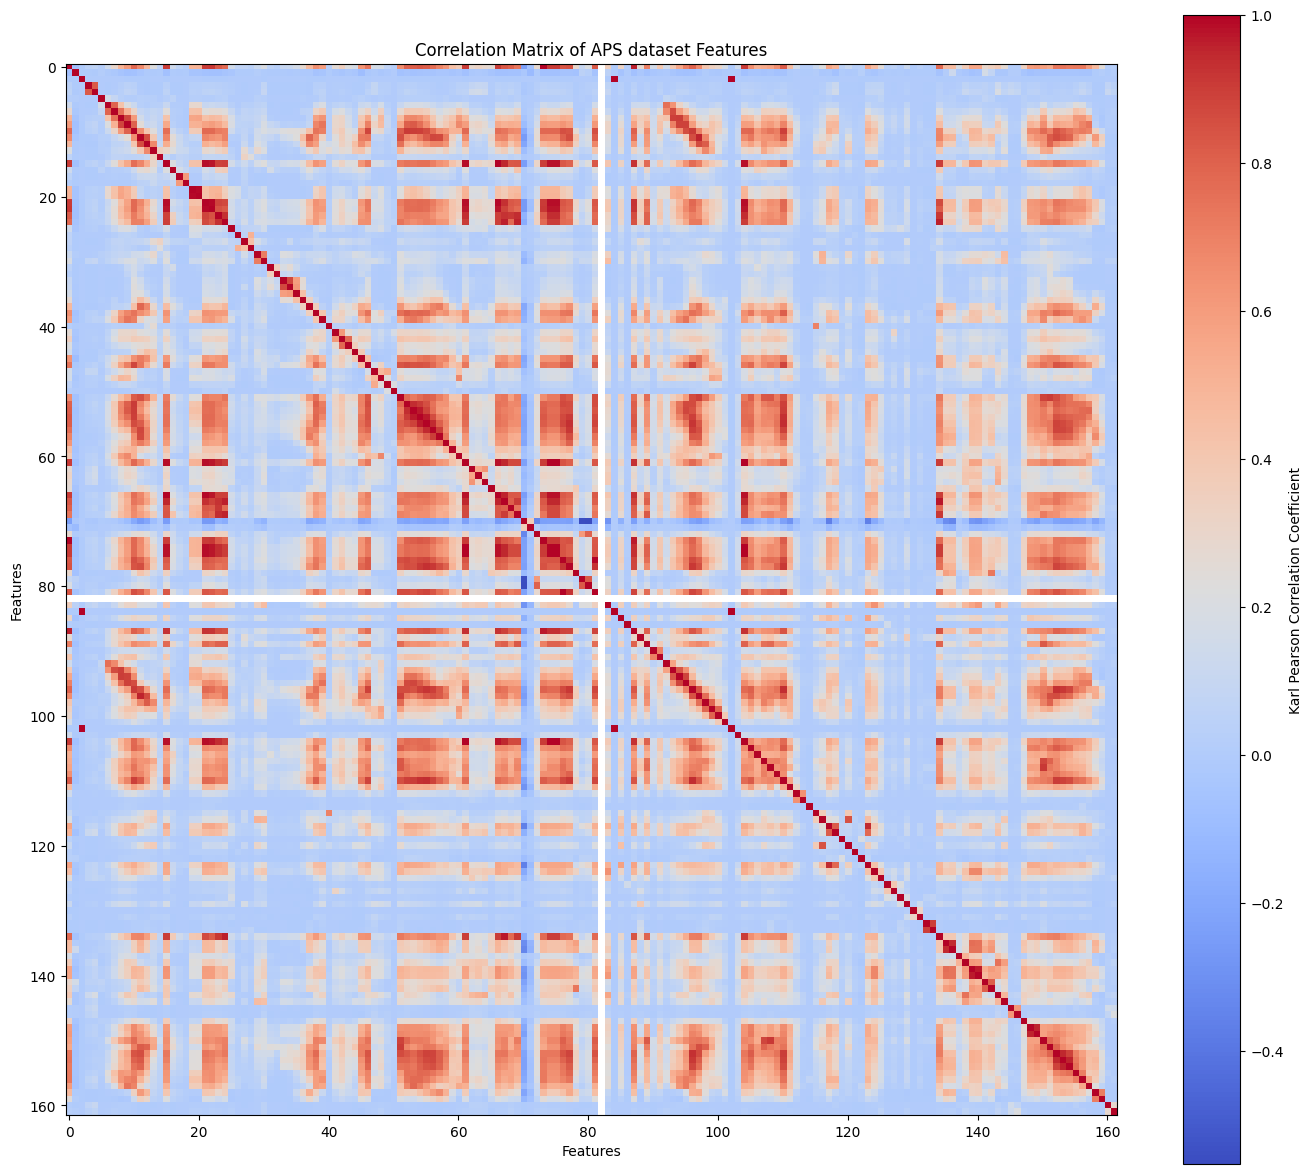

In [13]:
correlation_mtr = features.corr(method='pearson')
plt.figure(figsize=(14,12))
plt.imshow(correlation_mtr, cmap='coolwarm', interpolation='none')
plt.colorbar(label='Karl Pearson Correlation Coefficient')
plt.title('Correlation Matrix of APS dataset Features')
plt.xlabel('Features')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

#### (iv) Make scatter plots and box plots

In [14]:
x = np.floor(np.sqrt(170))
top_cv_features = cv_df.sort_values(by='CV', ascending=False).head(int(x))['Feature'].tolist()
top_cv_features

['cf_000',
 'co_000',
 'ad_000',
 'cs_009',
 'dh_000',
 'dj_000',
 'ag_000',
 'as_000',
 'ay_009',
 'ak_000',
 'az_009',
 'au_000',
 'ch_000']

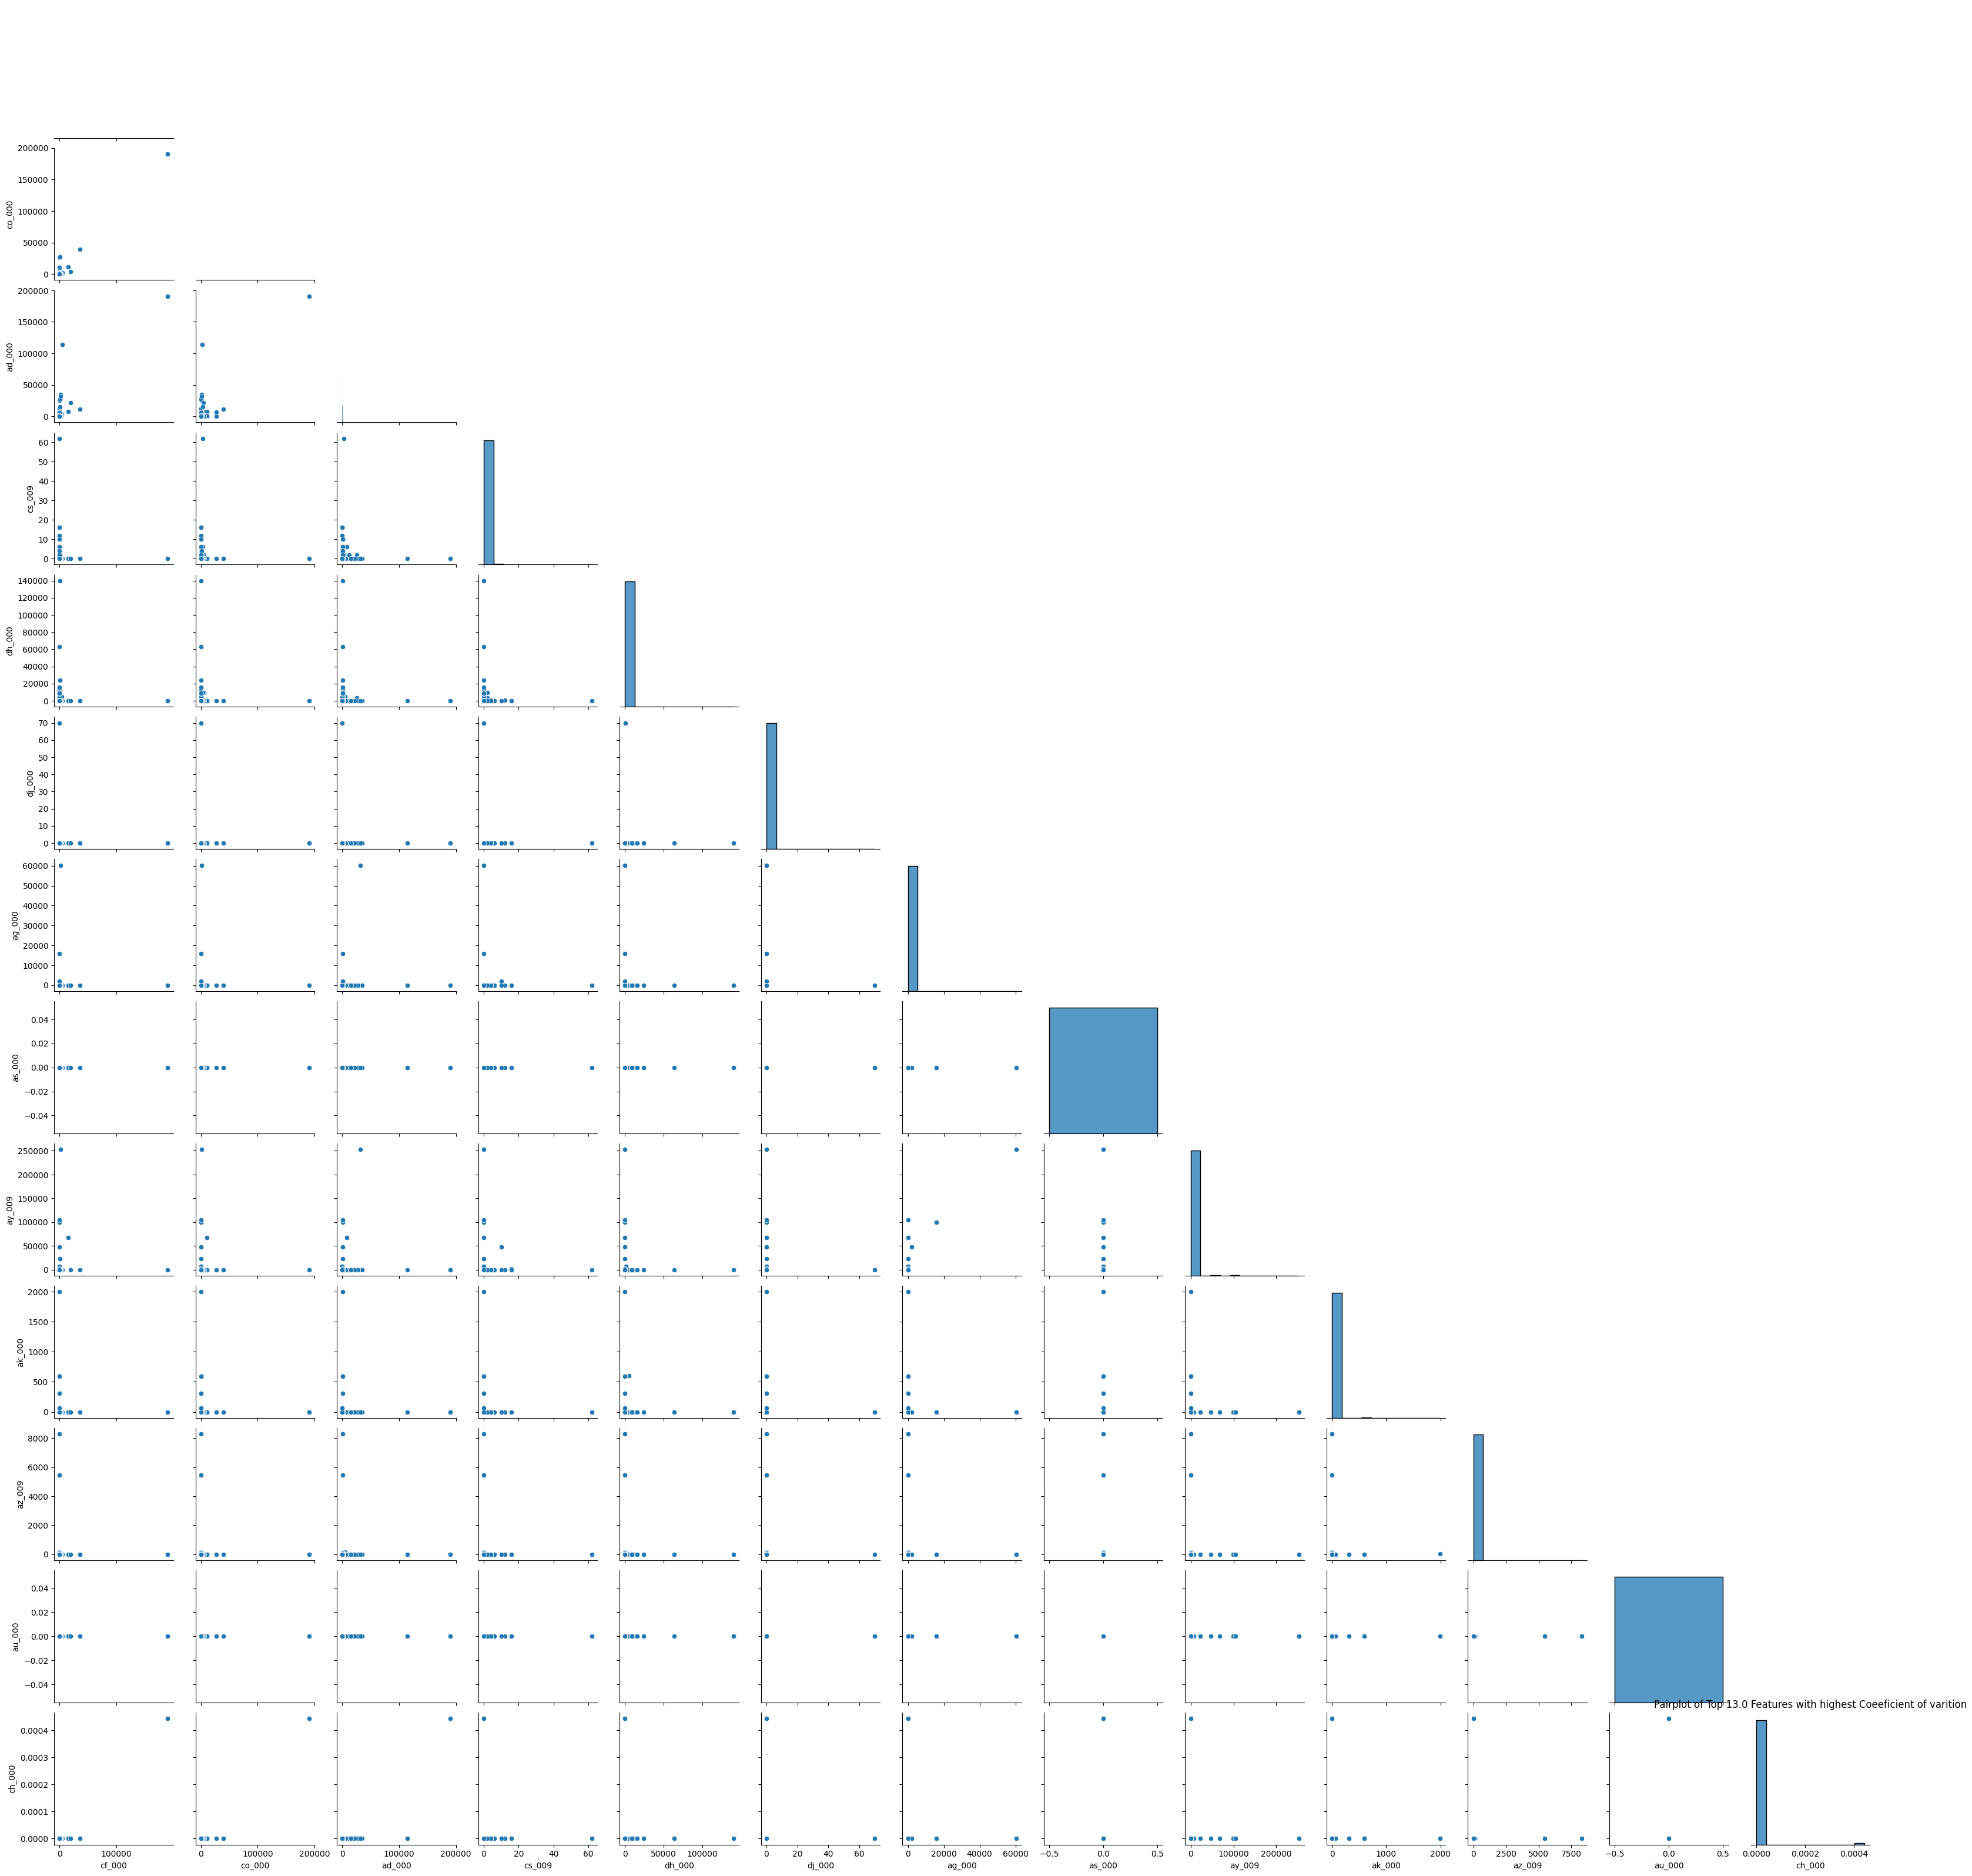

In [15]:
sns.pairplot(new_df_train[top_cv_features].sample(1000, random_state=42), corner=True)
plt.title(f"Pairplot of Top {x} Features with highest Coeeficient of varition")
# No hue
plt.show()

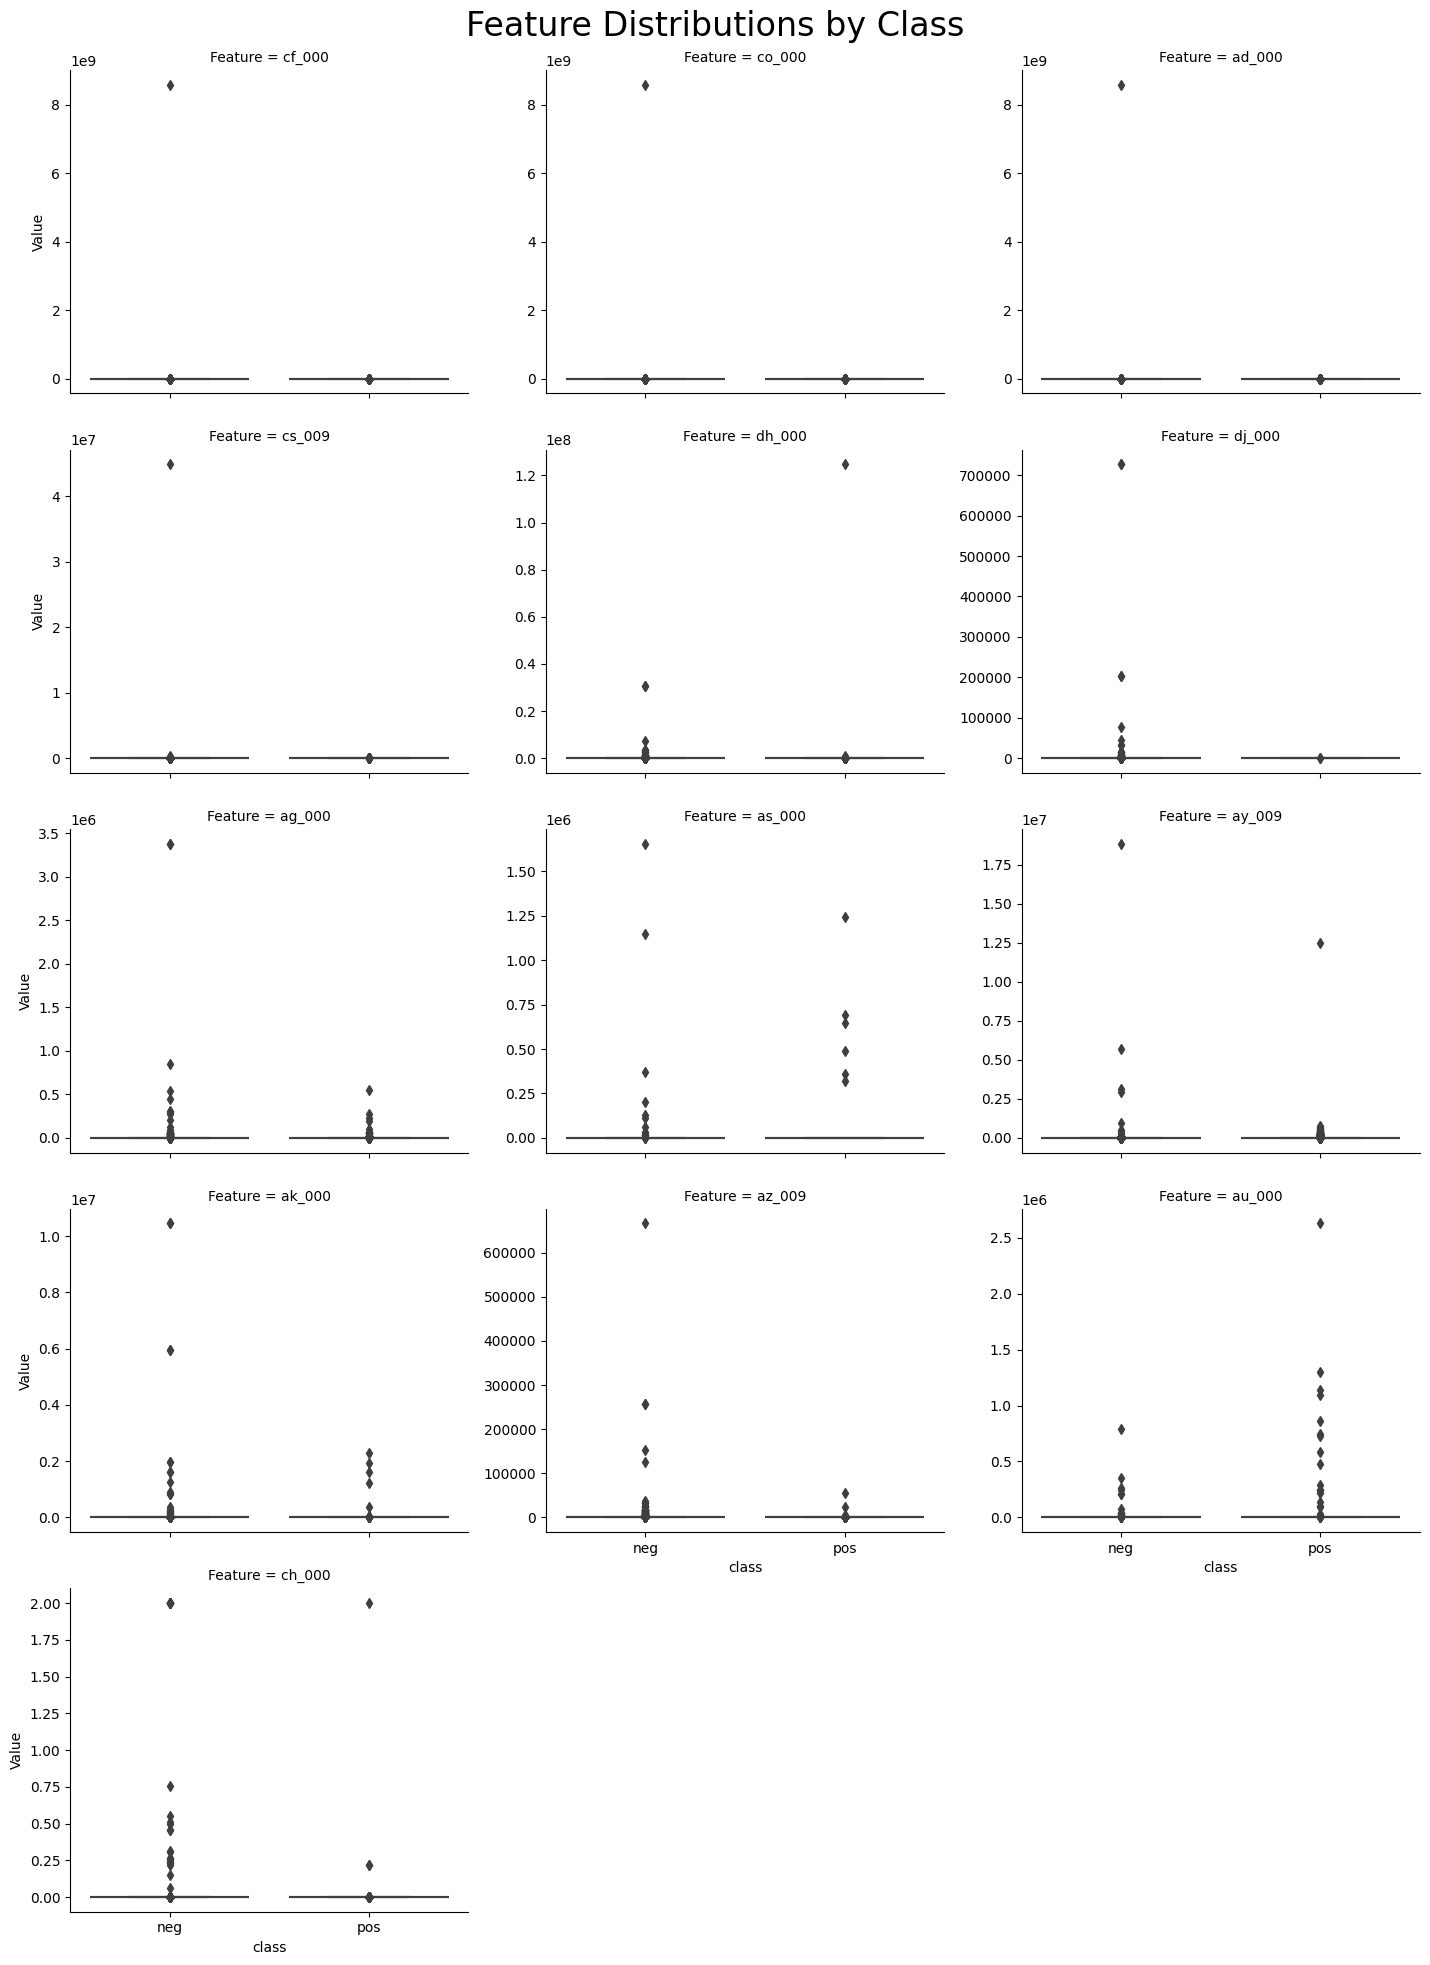

In [16]:
df_top_cv = new_df_train[top_cv_features + ['class']]
df_melted = df_top_cv.melt(id_vars='class', var_name='Feature', value_name='Value')
g = sns.catplot(
    data=df_melted, 
    x='class', 
    y='Value', 
    col='Feature', 
    kind='box', 
    col_wrap=3, 
    sharey=False,
    height=4, 
    aspect=1.2
)
g.set_xticklabels(['neg', 'pos'])
g.fig.subplots_adjust(top=0.95)
g.fig.suptitle('Feature Distributions by Class', fontsize=24)

plt.show()

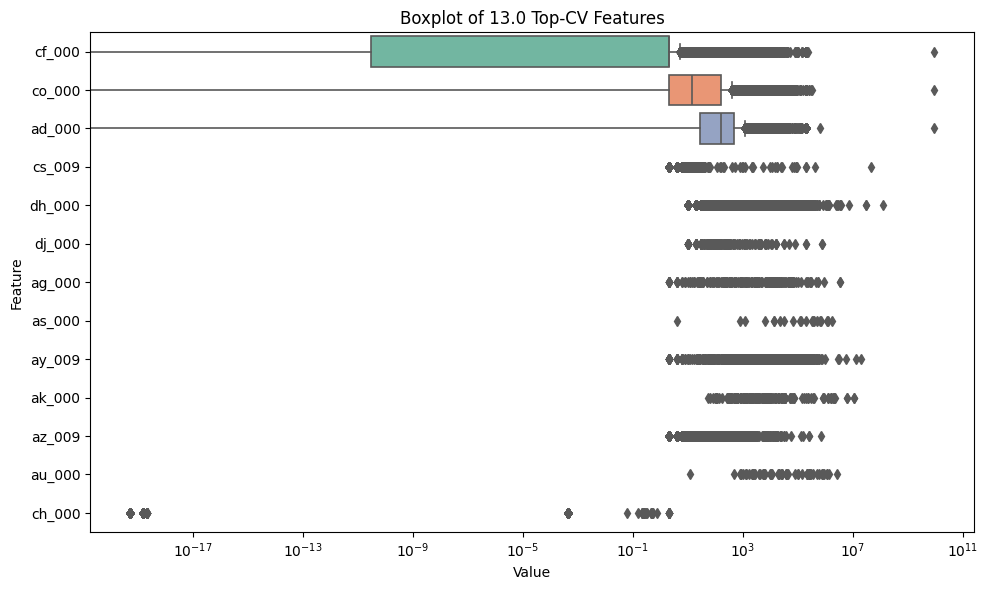

In [17]:
plt.figure(figsize=(10, 6))  
box_plot = sns.boxplot(
    data=df_top_cv,
    orient='h',
    showfliers=True,        
    linewidth=1.2,
    palette='Set2'           
)
box_plot.set(xscale="log")
plt.title(f"Boxplot of {x} Top-CV Features")
plt.xlabel("Value")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

#### The above plots alone are insufficient to cover all predictive significance, they are just qualitatve visuals

#### (v) Is this data set imbalanced?

In [18]:
print("\n For training instance one can observe that:")
print(f"\n The Class (Prediction Variable) has the following classes {new_df_train['class'].unique()}")
print(f"\n Where {new_df_train[new_df_train['class'] == 'neg'].shape[0]}")
print(f"\n or {(new_df_train[new_df_train['class'] == 'neg'].shape[0] / new_df_train.shape[0]) * 100} % are negative")
print(f"\n Where {new_df_train[new_df_train['class'] == 'pos'].shape[0]}")
print(f"\n or {(new_df_train[new_df_train['class'] == 'pos'].shape[0] / new_df_train.shape[0]) * 100} % are positive")
print(f"\n Which is a clearly an imbalance of classes")


 For training instance one can observe that:

 The Class (Prediction Variable) has the following classes ['neg' 'pos']

 Where 59000

 or 98.33333333333333 % are negative

 Where 1000

 or 1.6666666666666667 % are positive

 Which is a clearly an imbalance of classes


### (c) Train a random forest

In [20]:
new_df_test = comprehensive_imputer(df=test_df, cols_cat=test_cat, N=None)
new_df_test.isna().sum(axis=0)

class     0
aa_000    0
ac_000    0
ad_000    0
ae_000    0
         ..
ee_007    0
ee_008    0
ee_009    0
ef_000    0
eg_000    0
Length: 163, dtype: int64

In [ ]:
progress_save_utility(new_df_test, 'new_df_test.csv', True, False)

In [33]:
def plotcm(y_test, y_pred, title):
    cm = confusion_matrix(y_test, y_pred)
    display_cm = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['neg', 'pos'])
    display_cm.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

def plotrocauc(y_test, y_probs, title, y_w_probs:None):
    if y_w_probs is None:
        fpr, tpr, threshold = roc_curve(y_test, y_probs, pos_label='pos')
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'ROC Curve (AUC={roc_auc:.3f})')
        plt.plot([0, 1], [0, 1], 'k--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.legend(loc="lower right")
        plt.title(title)
        plt.show()
    else:
        fpr, tpr, threshold = roc_curve(y_test, y_probs, pos_label='pos')
        _fpr, _tpr, _threshold = roc_curve(y_test, y_w_probs, pos_label='pos')
        roc_auc = auc(fpr, tpr)
        _roc_auc = auc(_fpr, _tpr)
        plt.plot(fpr, tpr, label=f'ROC Curve for baseline (AUC={roc_auc:.3f})')
        plt.plot(_fpr, _tpr, label=f'ROC Curve for weighted (AUC={_roc_auc:.3f})')
        plt.plot([0, 1], [0, 1], 'k--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.legend(loc="lower right")
        plt.title(title)
        plt.show()

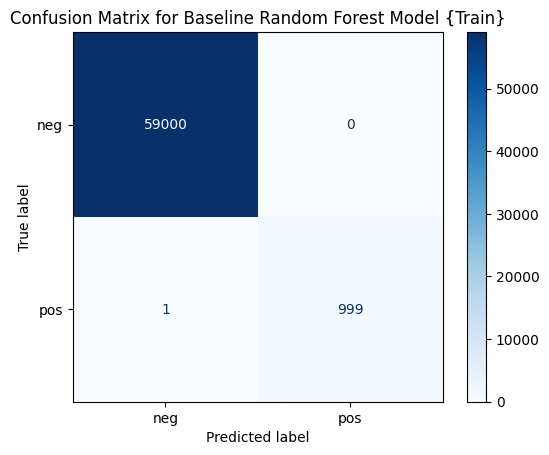

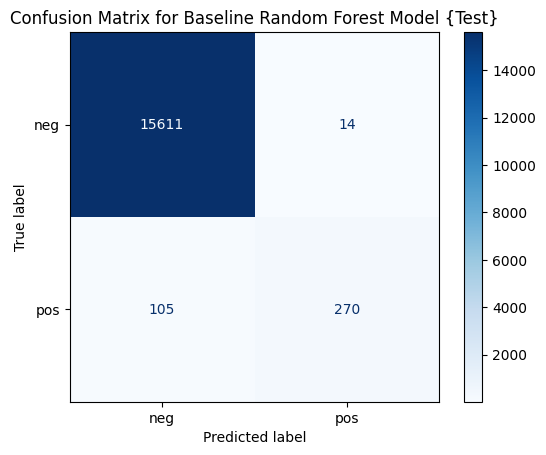


 Out of bag Error: 0.006

 Train Accuracy: 1.000

 Test Accuracy: 0.993

 Train Error: 0.000

 Test Error: 0.007

 Out of Bag Error is close to the test error indicating good generalization


In [18]:
X_train = new_df_train.iloc[:, 1:]
y_train = new_df_train.iloc[:, 0]
X_test = new_df_test.iloc[:, 1:]
y_test = new_df_test.iloc[:, 0]

model = RandomForestClassifier(
    n_estimators=100,
    oob_score=True,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_train_pred = model.predict(X_train)
plotcm(y_train, y_train_pred, "Confusion Matrix for Baseline Random Forest Model {Train}")
plotcm(y_test, y_pred, "Confusion Matrix for Baseline Random Forest Model {Test}")

y_train_probs = model.predict_proba(X_train)[:, 1]
y_probs = model.predict_proba(X_test)[:, 1]


outofbag_err = 1 - model.oob_score_
print(f"\n Out of bag Error: {outofbag_err:.3f}")

train_accu = accuracy_score(y_train, y_train_pred)
train_err = 1- train_accu

test_accu = accuracy_score(y_test, y_pred)
test_err = 1 - test_accu

print(f"\n Train Accuracy: {train_accu:.3f}")
print(f"\n Test Accuracy: {test_accu:.3f}")

print(f"\n Train Error: {train_err:.3f}")
print(f"\n Test Error: {test_err:.3f}")

if abs(outofbag_err - test_err) < 0.02:
    print("\n Out of Bag Error is close to the test error indicating good generalization")
else:
    print("\n Out of bag Error and test error differ significantly suggesting overfitting/overlearning of data")

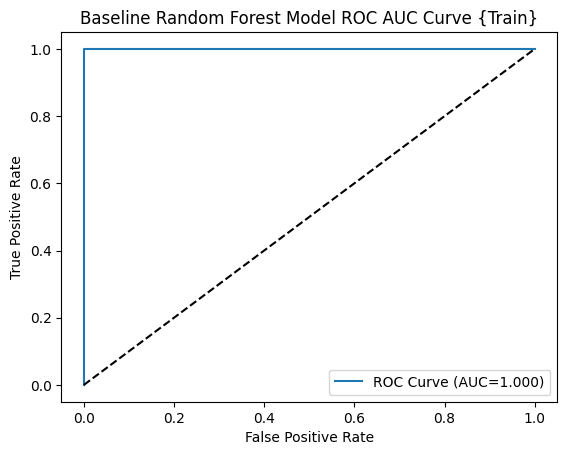

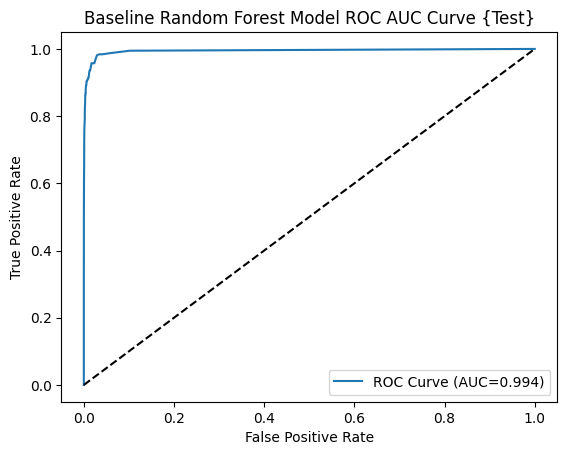

In [19]:
plotrocauc(y_train, y_train_probs, "Baseline Random Forest Model ROC AUC Curve {Train}")
plotrocauc(y_test, y_probs, "Baseline Random Forest Model ROC AUC Curve {Test}")

### (d) Research class imbalance in random forest


 Confusion Matrix Comparison between Weighted Random Forest Train Vs Test


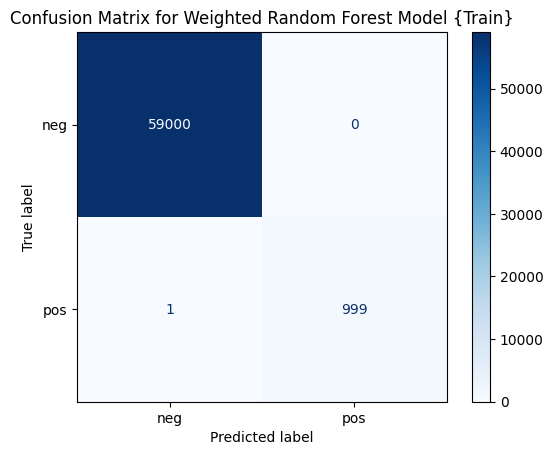

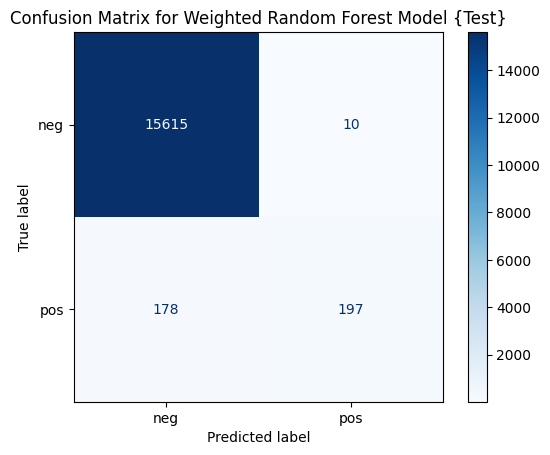

In [13]:
bal_model = RandomForestClassifier(
    n_estimators=100,
    oob_score = True,
    class_weight = "balanced_subsample",
    random_state = 42,
    n_jobs = -1)

bal_model.fit(X_train, y_train)

bal_y_pred_train = bal_model.predict(X_train)
bal_y_pred = bal_model.predict(X_test)

print("\n Confusion Matrix Comparison between Weighted Random Forest Train Vs Test")

plotcm(y_train, bal_y_pred_train, "Confusion Matrix for Weighted Random Forest Model {Train}")

plotcm(y_test, bal_y_pred, "Confusion Matrix for Weighted Random Forest Model {Test}")

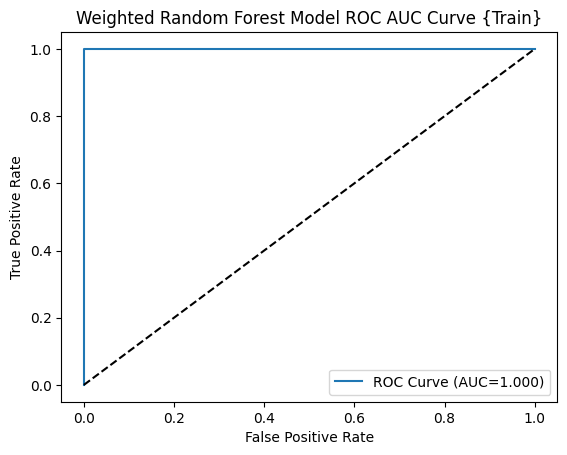

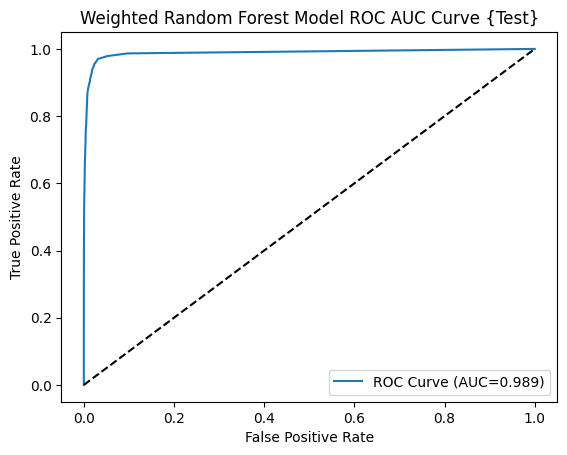

In [15]:
bal_y_probs_train = bal_model.predict_proba(X_train)[:, 1]
bal_y_probs = bal_model.predict_proba(X_test)[:, 1]

plotrocauc(y_train, bal_y_probs_train, "Weighted Random Forest Model ROC AUC Curve {Train}")
plotrocauc(y_test, bal_y_probs, "Weighted Random Forest Model ROC AUC Curve {Test}")


In [17]:
print("\n Random Forest Model vs Random Forest Model with class imbalance handling")
print("\n Baseline RF      Weighted RF")
bal_oob = 1 - bal_model.oob_score_
bal_acc = accuracy_score(y_test, bal_y_pred)
print("\n Accuracy {Test}: ")
print(f"\n Baseline RF: {test_accu}  Weighted RF: {bal_acc}")
print("\n Out of Bag Error: ")
print(f"\n Baseline RF: {outofbag_err:.3f}  Weighted RF: {bal_oob:.3f}")
bal_err = 1- bal_acc
print("\n Test Error")
print(f"\n Baseline RF: {test_err}  Weighted RF: {bal_err}")
print("\n Out of Bag Error - Test Error")
print("\n For Baseline RF")
if abs(outofbag_err - test_err) < 0.02:
    print("\n Out of Bag Error is close to the test error indicating good generalization")
else:
    print("\n Out of bag Error and test error differ significantly suggesting overfitting/overlearning of data")

print("\n For Weighted RF")
if abs(bal_oob - bal_err) < 0.02:
    print("\n Out of Bag Error is close to the test error indicating good generalization")
else:
    print("\n Out of bag Error and test error differ significantly suggesting overfitting/overlearning of data")


 Random Forest Model vs Random Forest Model with class imbalance handling

 Baseline RF      Weighted RF

 Accuracy {Test}: 

 Baseline RF: 0.9925625  Weighted RF: 0.98825

 Out of Bag Error: 

 Baseline RF: 0.006  Weighted RF: 0.008

 Test Error

 Baseline RF: 0.007437499999999986  Weighted RF: 0.011750000000000038

 Out of Bag Error - Test Error

 For Baseline RF

 Out of Bag Error is close to the test error indicating good generalization

 For Weighted RF

 Out of Bag Error is close to the test error indicating good generalization


<div>
<p>
Random Forest classifiers are inherently biased toward the majority class in imbalanced datasets because       they optimize overall classification accuracy. To address this, techniques such as class weighting,  undersampling, oversampling (e.g., SMOTE), and balanced random forests are commonly used.</p>
<p>
In this experiment, class imbalance was handled using class_weight="balanced_subsample", which assigns higher weights to the minority class during training. This ensures that misclassification of minority samples is penalized more heavily.
</p>

<p>
Comparing the baseline and weighted Random Forest models:<br/>
1. The baseline model achieved higher accuracy and lower test error, indicating better performance on the majority class.<br/>
2. The weighted model showed slightly lower accuracy but improved ROC AUC, indicating better discrimination between classes.<br/>
    
<p>The decrease in accuracy is expected because the model sacrifices some performance on the majority class to improve predictions on the minority class.
</p>
<p>
Additionally, the Out-of-Bag (OOB) error was close to the test error for both models, indicating good generalization.
</p>
<p>
Overall, the weighted Random Forest provides a more balanced and reliable model for imbalanced classification, as it improves the detection of the minority class, which is often more important in real-world applications.  
</p>
</div>

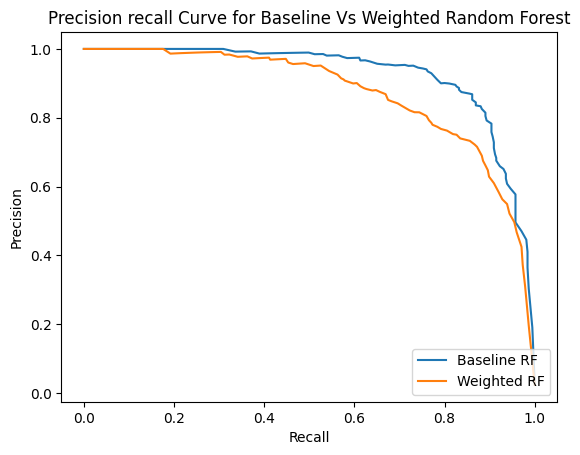

In [23]:
baseline_precision, baseline_recall, _ = precision_recall_curve(y_test, y_probs, pos_label='pos')
weighted_precision, weighted_recall, _ = precision_recall_curve(y_test, bal_y_probs, pos_label='pos')

plt.plot(baseline_recall, baseline_precision, label="Baseline RF")
plt.plot(weighted_recall, weighted_precision, label="Weighted RF")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc="lower right")
plt.title("Precision recall Curve for Baseline Vs Weighted Random Forest")
plt.show()

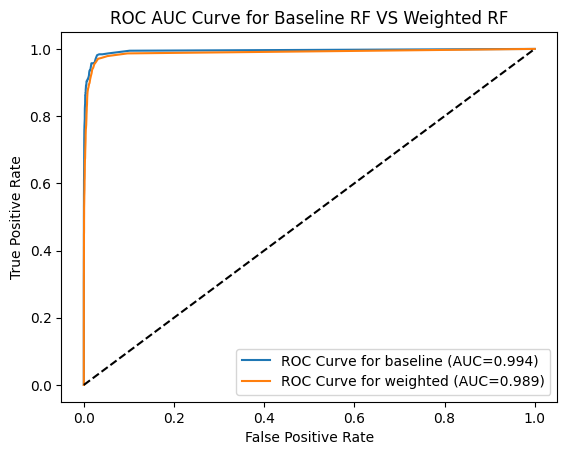

In [34]:
plotrocauc(y_test, y_probs, "ROC AUC Curve for Baseline RF VS Weighted RF", bal_y_probs)

### (e) XGBoost and Model Trees

In [39]:
y_train = y_train.map({'neg': 0, 'pos': 1})
y_test = y_test.map({'neg': 0, 'pos': 1})

In [40]:
param_grid = {
    'reg_alpha': [0, 0.1, 1, 10]
}

grid = GridSearchCV(
    XGBClassifier(
        objective='binary:logistic',
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        eval_metric="auc",
        random_state=42
    ),
    param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_
print("Best alpha:", grid.best_params_)
print("CV AUC:", grid.best_score_)

Best alpha: {'reg_alpha': 0}
CV AUC: 0.9912449152542374


In [42]:
cv_error = 1 - grid.best_score_
print("Cross-validation error:", cv_error)

Cross-validation error: 0.008755084745762587


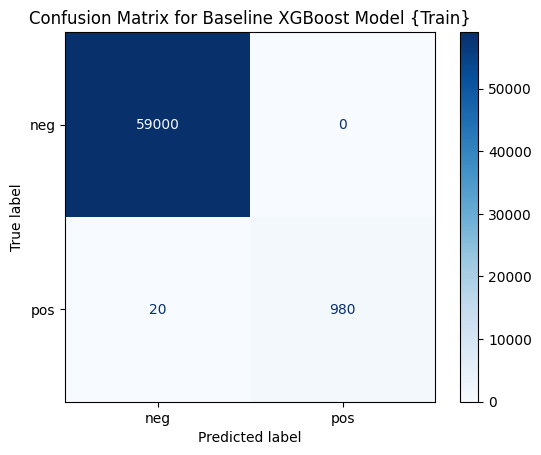

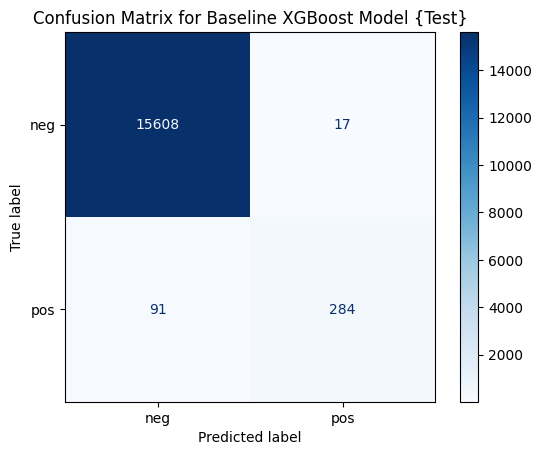


 Baseline XGB Model Training Accuracy: 0.9996666666666667

 Baseline XGB Model Testing Accuracy: 0.99325


In [49]:
xgb_model = XGBClassifier(
    objective='binary:logistic',
    n_estimators=300,
    random_state=42,
    eval_metric="auc",
    max_depth=4,
    reg_alpha=0,
    learning_rate=0.1,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)
    
xgb_y_pred_train = xgb_model.predict(X_train)
xgb_y_pred = xgb_model.predict(X_test)

plotcm(y_train, xgb_y_pred_train, "Confusion Matrix for Baseline XGBoost Model {Train}")
plotcm(y_test, xgb_y_pred, "Confusion Matrix for Baseline XGBoost Model {Test}")

xgb_y_train_probs = xgb_model.predict_proba(X_train)[:, 1]
xgb_y_probs = xgb_model.predict_proba(X_test)[:, 1]


xgb_train_accu = accuracy_score(y_train, xgb_y_pred_train)
xgb_train_err = 1- xgb_train_accu

xgb_test_accu = accuracy_score(y_test, xgb_y_pred)
xgb_test_err = 1 - xgb_test_accu

print(f"\n Baseline XGB Model Training Accuracy: {xgb_train_accu}")
print(f"\n Baseline XGB Model Testing Accuracy: {xgb_test_accu}")

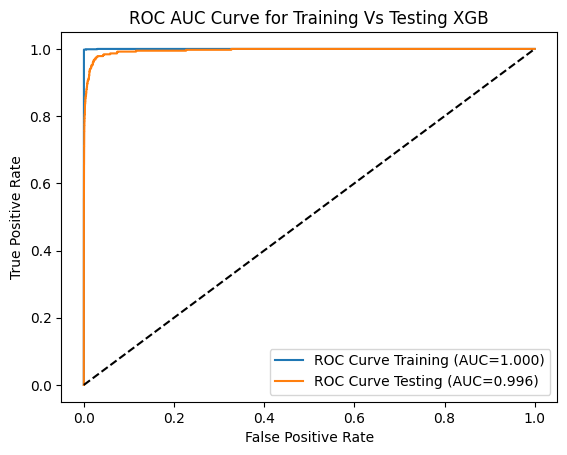

In [52]:
fpr_train, tpr_train, _ = roc_curve(y_train, xgb_y_train_probs)
fpr_test, tpr_test, _ = roc_curve(y_test, xgb_y_probs)

roc_auc = auc(fpr_train, tpr_train)
_roc_auc =auc(fpr_test, tpr_test)
plt.plot(fpr_train, tpr_train, label=f'ROC Curve Training (AUC={roc_auc:.3f})')
plt.plot(fpr_test, tpr_test, label=f'ROC Curve Testing (AUC={_roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.title("ROC AUC Curve for Training Vs Testing XGB")
plt.show()

<div>
    <p>
    Cross-validation selected α = 0, indicating that L1 regularization was not necessary for this dataset. This suggests that the model does not suffer significantly from overfitting and that feature selection is effectively handled by the tree-based structure of XGBoost.
    </p>
</div>

### (f) Use SMOTE to pre-process your data

In [64]:
sm = SMOTE(random_state=42, sampling_strategy='auto')
X_train_, y_train_ = sm.fit_resample(X_train, y_train)
X_test_, y_test_ = sm.fit_resample(X_test, y_test)
xgb_sm = XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42,
    n_estimators=300,
    learning_ratio=0.1,
    max_depth=6,
    reg_alpha=1,
    n_jobs=-1
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(xgb_sm, X_train_, y_train_, cv=cv, scoring="roc_auc", n_jobs=-1)
print(f"Cross vcalidation AUC Score with SMOTE and mean of 5 folds: {scores.mean():.3f}")

Cross vcalidation AUC Score with SMOTE and mean of 5 folds: 1.000


(118000, 162) (118000,)


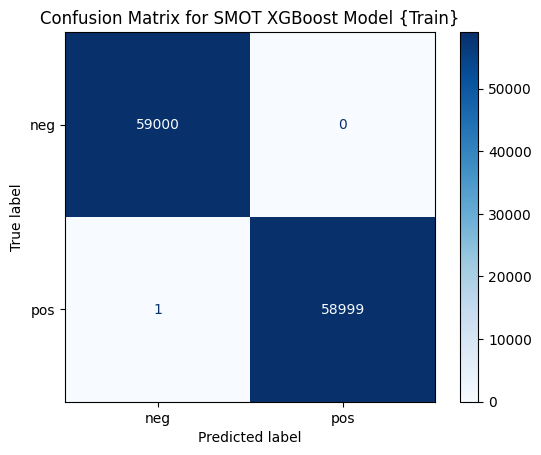

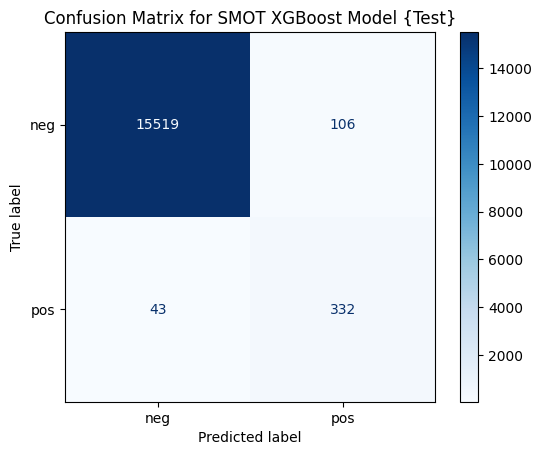


 Baseline XGB Model Training Accuracy: 0.9999915254237288

 Baseline XGB Model Training Error: 8.47457627117798e-06

 Baseline XGB Model Testing Accuracy: 0.9906875

 Baseline XGB Model Testing Error: 0.009312499999999946


In [67]:
print(X_train_.shape, y_train_.shape)
xgb_sm.fit(X_train_, y_train_)

xgb_sm_y_pred_train = xgb_sm.predict(X_train_)
xgb_sm_y_pred = xgb_sm.predict(X_test)

xgb_sm_y_train_probs = xgb_sm.predict_proba(X_train_)[:, 1]
xgb_sm_y_probs = xgb_sm.predict_proba(X_test)[:, 1]

plotcm(y_train_, xgb_sm_y_pred_train, "Confusion Matrix for SMOT XGBoost Model {Train}")
plotcm(y_test, xgb_sm_y_pred, "Confusion Matrix for SMOT XGBoost Model {Test}")

xgb_sm_train_accu = accuracy_score(y_train_, xgb_sm_y_pred_train)
xgb_sm_train_err = 1- xgb_sm_train_accu

xgb_sm_test_accu = accuracy_score(y_test, xgb_sm_y_pred)
xgb_sm_test_err = 1 - xgb_sm_test_accu

print(f"\n Baseline XGB Model Training Accuracy: {xgb_sm_train_accu}")
print(f"\n Baseline XGB Model Training Error: {xgb_sm_train_err}")
print(f"\n Baseline XGB Model Testing Accuracy: {xgb_sm_test_accu}")
print(f"\n Baseline XGB Model Testing Error: {xgb_sm_test_err}")

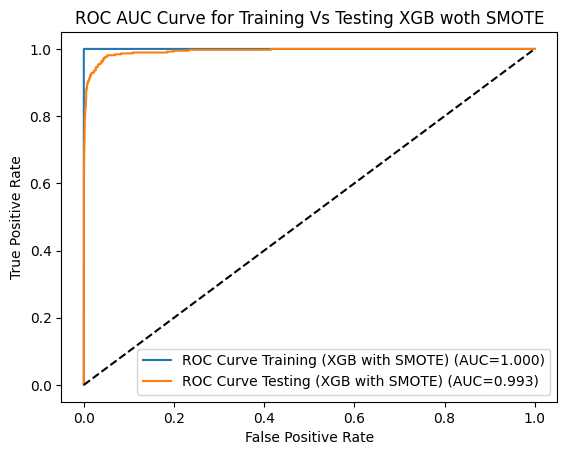

In [68]:
fpr_train_, tpr_train_, _ = roc_curve(y_train_, xgb_sm_y_train_probs)
fpr_test_, tpr_test_, _ = roc_curve(y_test, xgb_sm_y_probs)

roc_auc_ = auc(fpr_train_, tpr_train_)
_roc_auc_ =auc(fpr_test_, tpr_test_)
plt.plot(fpr_train_, tpr_train_, label=f'ROC Curve Training (XGB with SMOTE) (AUC={roc_auc_:.3f})')
plt.plot(fpr_test_, tpr_test_, label=f'ROC Curve Testing (XGB with SMOTE) (AUC={_roc_auc_:.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.title("ROC AUC Curve for Training Vs Testing XGB woth SMOTE")
plt.show()

<div>
<p>
To address class imbalance, SMOTE (Synthetic Minority Over-sampling Technique) was applied within each cross-validation fold using a pipeline to avoid data leakage. SMOTE generates synthetic samples of the minority class, thereby balancing the dataset and improving the model’s ability to learn minority class patterns.
The performance of the SMOTE-enhanced XGBoost model was compared with the baseline XGBoost model trained on the imbalanced dataset. The baseline model achieved higher overall accuracy, but this was primarily due to its bias toward the majority class. As a result, it failed to correctly classify many minority class instances.
</p>
</div>

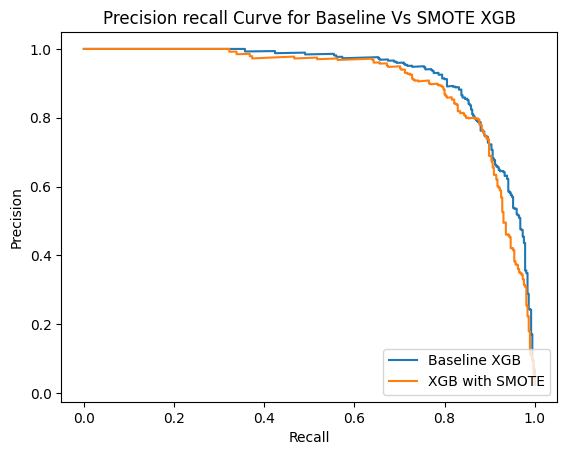

In [70]:
xgb_precision, xgb_recall, _ = precision_recall_curve(y_test, xgb_y_probs)
xgb_sm_precision, xgb_sm_recall, _ = precision_recall_curve(y_test, xgb_sm_y_probs)

plt.plot(xgb_recall, xgb_precision, label="Baseline XGB")
plt.plot(xgb_sm_recall, xgb_sm_precision, label="XGB with SMOTE")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc="lower right")
plt.title("Precision recall Curve for Baseline Vs SMOTE XGB")
plt.show()

<div>
<p>
The ROC AUC scores for both models were comparable, indicating similar ranking performance. However, the SMOTE model demonstrated improved recall and F1-score, which are more appropriate metrics for imbalanced classification problems.
Overall, the SMOTE-enhanced XGBoost model provides a more reliable and balanced classifier, particularly for detecting rare events, and is therefore preferred over the baseline model.
</p>
</div>

## 2. ISLR 6.6.3

<div>
<p>a.
<ul>
<li>
Explanation: The RSS will smoothly but steadily decrease as the value of 's' increases, RSS decreases monotonically, meaning it definitely does not go up, it can stay the same or decrease
</li>
<li>i. <b>Not Correct.</b>
</li>
<li>
ii. <b>Not Correct</b>
</li>
<li>
iii. <b> Not Correct</b>
</li>
<li>
iv. <b>Correct</b> because the model becomes flexiblr and fits training data more closely
</li>
<li>
v. <b>Correct</b>
</li>
</ul>
</p>
</div>

<div>
<p>b.
<ul>
<li>
Explanation: For Small s, the model will be too simple, hence underfit and give a high test RSS, for a moderate s the model will be a little better fit and hence RSS will decrease, finally again as s increases the model will be too flexible and overfit causing a test RSS increase, and hence we observe a 'U' shaped curve.
</li>
<li>
i. <b>Not Correct</b> 
</li>
<li>
ii. <b>Correct</b>
</li>
<li>
iii. <b> Not Correct</b>
</li>
<li>
iv. <b>Not Correct</b>
</li>
<li>
v. <b>Not Correct</b>
</li>
</ul>
</p>
</div>

<div>
<p>c.
<ul>
<li>
Explanation: Increasing s means less constraint, and a more flexible model, flexible models are more sensitive to training data, so variance incereases monotonically
</li>
<li>
i. <b>Not Correct</b> 
</li>
<li>
ii. <b>Not Correct</b>
</li>
<li>
iii. <b>Correct</b>
</li>
<li>
iv. <b>Not Correct</b>
</li>
<li>
v. <b>Not Correct</b>
</li>
</ul>
</p>
</div>

<div>
<p>d.
<ul>
<li>
Explanation: A smaller 's' means poor approximation, a very constrained model and a high bias, as the value of 's' increases, the model becmose for flexible, and closer to true functiob, variances increases and bias decreases monotonically.
</li>
<li>
i. <b>Not Correct</b> 
</li>
<li>
ii. <b>Not Correct</b>
</li>
<li>
iii. <b>Not Correct</b>
</li>
<li>
iv. <b>Correct</b>
</li>
<li>
v. <b>Not Correct</b>
</li>
</ul>
</p>
</div>

<div>
<p>e.
<ul>
<li>
Explanation: The noise is inherent in the data, and does not depend on the model, so the Irreducible error stays constant.
</li>
<li>
i. <b>Not Correct</b> 
</li>
<li>
ii. <b>Not Correct</b>
</li>
<li>
iii. <b>Not Correct</b>
</li>
<li>
iv. <b>Not Correct</b>
</li>
<li>
v. <b>Correct</b>
</li>
</ul>
</p>
</div>

## 3. ISLR 6.6.5

<div>
<p>
a.
<ul>
<li>
With ^𝛽_0 = 0 and the two predictors identical,
X11 = X12, X21 = X22
the ridge regression problem becomes <br/>
<div>min<h6>(β1,β2)</h6>(yi − β1Xi1 - β2Xi2)**2 + λ(β1**2 + β2**2)</div>
</li>
</ul>
</p>
</div>

<div>
<p>
b.
<ul>
<li>
For ridge regression, the penalty \((\hat\beta_1 + \hat\beta_2\))^2 is strictly convex, so the overall optimization problem has a unique minimizer. Therefore the two minimizers must be the same:
(\(\hat\beta_1, \hat\beta_2\)) = (\(\hat\beta_2, \hat\beta_1\)), which implies, \(\hat\beta_1 = \hat\beta_2\) <br/>
So the ridge coefficient estimates satisfy \(\hat\beta_1 = \hat\beta_2\)
</li>
</ul>
</p>
</div>

<div>
<p>
c.
<ul>
<li>
    With \(\hat\beta_0 = 0\) and \(x_{11} = x_{12}\), \(x_{21} = x_{22}\), the lasso optimization problem is:
  </p>

  <p>
    \[
    \min_{\beta_1,\beta_2}
    \sum_{i=1}^{2}\left(y_i-\beta_1 x_{i1}-\beta_2 x_{i2}\right)^2
    + \lambda\left(|\beta_1|+|\beta_2|\right)
    \]
  </p>
</li>
</ul>
</p>
</div>

<div>
<p>
c.
<ul>
<li>
  <p>
    The lasso coefficients are <strong>not unique</strong> in this setting because the two predictors are identical:
    \(x_{11}=x_{12}\) and \(x_{21}=x_{22}\). As a result, the fitted value depends only on the
    <strong>sum</strong> \(\beta_1+\beta_2\), not on the individual values of \(\beta_1\) and \(\beta_2\).
  </p>

  <p>
    The lasso objective can be written as
    \[
    \min_{\beta_1,\beta_2}
    \left(y_1-(\beta_1+\beta_2)x_{11}\right)^2
    +
    \left(y_2-(\beta_1+\beta_2)x_{21}\right)^2
    + \lambda\left(|\beta_1|+|\beta_2|\right).
    \]
  </p>

  <p>
    For a fixed value \(c=\beta_1+\beta_2\), the squared-error part is the same for every pair
    \((\beta_1,\beta_2)\) with that sum. Also, by the triangle inequality,
    \[
    |\beta_1|+|\beta_2| \ge |\beta_1+\beta_2| = |c|.
    \]
    Equality holds whenever \(\beta_1\) and \(\beta_2\) have the same sign and their sum is \(c\).
  </p>

  <p>
    Therefore, if the optimal value of the sum is \(c^*\), then every pair \((\beta_1,\beta_2)\) such that
    \[
    \beta_1+\beta_2=c^*
    \]
    and \(\beta_1,\beta_2\) have the same sign as \(c^*\) gives the same minimum value of the objective.
  </p>

  <p>
    So the solutions are:
  </p>

  <ul>
    <li>
      If \(c^*>0\), then all pairs with
      \[
      \beta_1=t,\quad \beta_2=c^*-t,\quad 0\le t\le c^*
      \]
      are optimal.
    </li>
    <li>
      If \(c^*<0\), then all pairs with
      \[
      \beta_1=t,\quad \beta_2=c^*-t,\quad c^*\le t\le 0
      \]
      are optimal.
    </li>
    <li>
      If \(c^*=0\), then the only solution is
      \[
      \beta_1=\beta_2=0.
      \]
    </li>
  </ul>
</li>
</ul>
</p>
</div>

## 4. ISLR 8.4.5

<div>
<ul>
<li>
Majority Vote Approach: <br/>
    Given the ten trees predict <br/>
    0.1, 0.15,0.2,0.2,0.55,0.6,0.6,0.65,0.7, and 0.75 <br/>
    6 out of 10 predict the class as 'Red', hence by majority vote, the final prediction is 'Red'
</li>
<li>
Average Probability Approach: <br/>
    (0.1 + 0.15 + 0.2 + 0.2 + 0.55 + 0.6 + 0.6 + 0.65 + 0.7 + 0.75) / 10 = 4.5/10 = 0.45 <br/>
    The average probability is 0.45 < 0.5, hence the final classification is 'Green'
</li>
</ul>
</div>

## 5. ISLR 9.7.3

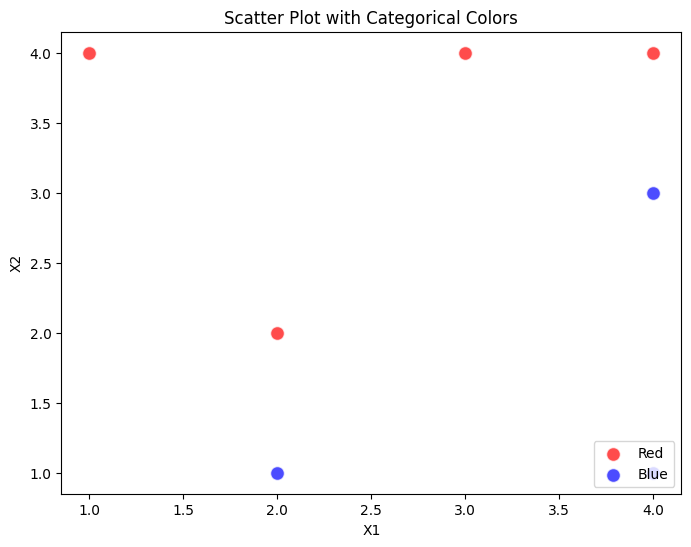

In [37]:
"""
(a) Lets constructr and sketch the given data
"""
samples = 7
x1 = np.array([3,2,4,1,2,4,4])
x2 = np.array([4,2,4,4,1,3,1])
y = np.array(['Red','Red','Red','Red','Blue','Blue','Blue'])

toy_df = pd.DataFrame({'X1': x1, 'X2': x2, 'Y': y})
toy_df.head(7)

plt.figure(figsize=(8, 6))
for color in toy_df['Y'].unique():
    subset = toy_df[toy_df['Y'] == color]
    plt.scatter(subset['X1'], subset['X2'], c=color.lower(), label=color, alpha=0.7, edgecolors='w', s=100)
plt.legend(loc="lower right")
plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Scatter Plot with Categorical Colors')

plt.show()



β0: 1.000 β1: -1.999, β2: 1.999


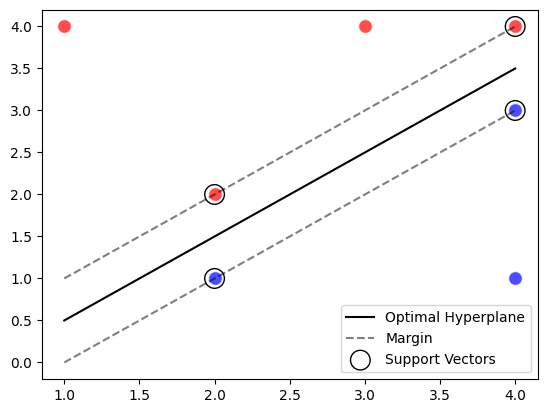

In [38]:
"""
(b) Let's sketch the optimal hyperplane And we can see the Optimal Hyperplane line divides the two classes
"""
from sklearn.svm import SVC

toy_df['Y_num'] = toy_df['Y'].map({'Red': 1, 'Blue': 0})
X = toy_df[['X1', 'X2']]
y = toy_df['Y_num']

clf = SVC(kernel='linear', C=1000000)
clf.fit(X, y)

w = clf.coef_[0]
b = clf.intercept_[0]
print(f"\nβ0: {b:.3f} β1: {w[0]:.3f}, β2: {w[1]:.3f}")
x1_vals = np.linspace(toy_df['X1'].min(), toy_df['X1'].max(), 100)
x2_hyperplane = -(w[0] / w[1]) * x1_vals - (b / w[1])

margin = 1 / np.sqrt(np.sum(clf.coef_ ** 2))
x2_margin_up = x2_hyperplane + (np.sqrt(1 + (w[0]/w[1])**2) * margin)
x2_margin_down = x2_hyperplane - (np.sqrt(1 + (w[0]/w[1])**2) * margin)

plt.plot(x1_vals, x2_hyperplane, 'k-', label='Optimal Hyperplane')
plt.plot(x1_vals, x2_margin_up, 'k--', alpha=0.5, label='Margin')
plt.plot(x1_vals, x2_margin_down, 'k--', alpha=0.5)
for color in toy_df['Y'].unique():
    subset = toy_df[toy_df['Y'] == color]
    plt.scatter(subset['X1'], subset['X2'], c=color.lower(), alpha=0.7, edgecolors='w', s=100)
plt.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1], 
            s=200, facecolors='none', edgecolors='black', label='Support Vectors')
plt.legend(loc="lower right")
plt.show()


<div>
<p>
c.
<ul>
<li>
So if, \(\beta_0 + \beta_1 x_{1} + \beta_2 x_2 \) > 0 theb classify as 'Red', otherwise 'Blue' <br/>
We have β0 = 1.000 β1 = -1.999 ~ -2, β2 = 1.999 ~ 2 <br/>
\(1 -2 x_{1} + 2 x_2 \) > 0 <br/>
\(x_{1} - x_2 \) < 0.5 the points below this line are classified as 'Blue' and above it are classified as 'Red'
</li>
</ul>
</p>
</div>

<div>
<p>
d.
<ul>
<li>
The margin can be observed in th above figure depicted with the dotted lines
</li>
</ul>
</p>
</div>

<div>
<p>
e.
<ul>
<li>
From the above figure:<br/>
The Support Vector for Red is (2,2) and (4.4)<br/>
The Support Vector for Blue is (2,1) and (4,3)
</li>
</ul>
</p>
</div>

f.
<ul>
<li>
A small movemment of (1, 4) would not change the optimal hyperplane, the movement should be significantly large and across the margin in order to make any difference
</li>
</ul>
</p>
</div>





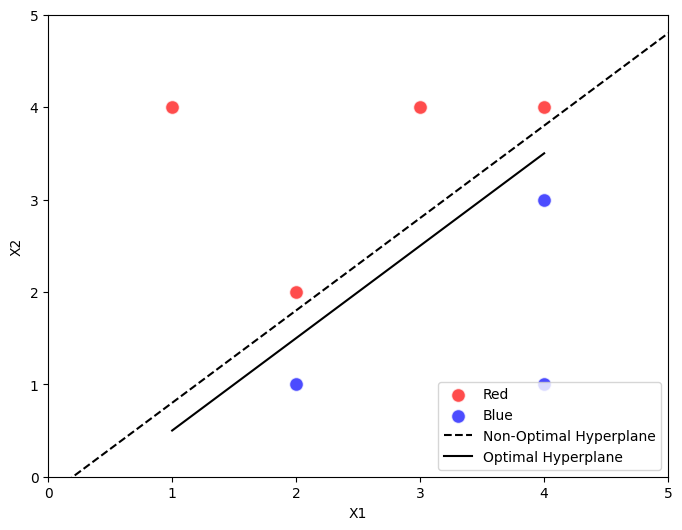

In [39]:
"""(g)"""
plt.figure(figsize=(8, 6))
for color in toy_df['Y'].unique():
    subset = toy_df[toy_df['Y'] == color]
    plt.scatter(subset['X1'], subset['X2'], c=color.lower(), label=color, alpha=0.7, edgecolors='w', s=100)

x_vals = np.linspace(0, 5, 100)
y_vals = x_vals - 0.2

plt.plot(x_vals, y_vals, '--k', label='Non-Optimal Hyperplane')
plt.plot(x1_vals, x2_hyperplane, 'k-', label='Optimal Hyperplane')
plt.xlim(0, 5)
plt.ylim(0, 5)

plt.legend(loc="lower right")
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()

<div>
<p>
Equation for the non-optimal hyperplane is -->
\(x_{1} - x_2 \) = 0.2
</p>
</div>

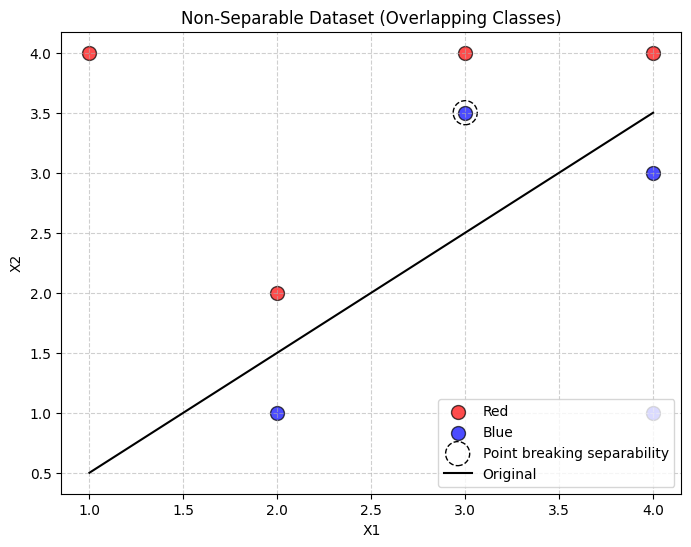

In [47]:
"""(h)"""
x1_new = np.array([3,2,4,1,2,4,4,3])
x2_new = np.array([4,2,4,4,1,3,1,3.5])
y_new = np.array(['Red','Red','Red','Red','Blue','Blue','Blue', 'Blue'])

toy_df_new = pd.DataFrame({'X1': x1_new, 'X2': x2_new, 'Y': y_new})

plt.figure(figsize=(8, 6))
for color in toy_df_new['Y'].unique():
    subset = toy_df_new[toy_df_new['Y'] == color]
    plt.scatter(subset['X1'], subset['X2'], c=color.lower(), label=color, alpha=0.7, edgecolors='k', s=100)

plt.scatter(3, 3.5, facecolors='none', edgecolors='black', s=300, label='Point breaking separability', linestyle='--')
plt.plot(x1_vals, x2_hyperplane, 'k-', label='Original')
plt.xlabel('X1')
plt.ylabel('X2')
plt.legend(loc='lower right')
plt.title('Non-Separable Dataset (Overlapping Classes)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()